In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(f'{dataset}/data.zarr', nthreads=4)
run = ds.pipeline.open(label='docs_default')

In [2]:
input_directory = TemporaryDirectory()
gmt_path = Path(input_directory.name) / 'pbmc_signatures.gmt'
gmt_path.write_text(
    'T_cell\tna\tCD3D\tCD3E\tTRAC\tLTB\tIL7R\n'
    'B_cell\tna\tMS4A1\tCD79A\tCD37\tCD74\tHLA-DRA\n'
    'Myeloid\tna\tLST1\tS100A8\tS100A9\tCTSS\tFCER1G\n',
    encoding='utf-8',
)
gene_sets = scarf.read_gmt(gmt_path)
gene_sets

,source,target
0,T_cell,CD3D
1,T_cell,CD3E
2,T_cell,TRAC
3,T_cell,LTB
4,T_cell,IL7R
5,B_cell,MS4A1
6,B_cell,CD79A
7,B_cell,CD37
8,B_cell,CD74
9,B_cell,HLA-DRA


In [3]:
available = {str(name).upper() for name in ds.RNA.feats.fetch_all('names')}
(
    gene_sets.assign(
        matched=gene_sets['target'].str.upper().isin(available),
    )
    .groupby('source')['matched']
    .agg(['sum', 'count'])
)

,sum,count
source,,
B_cell,5,5
Myeloid,5,5
T_cell,5,5


In [4]:
cell_selection = run['analysis_cell_selection']
all_features = ds.select_all_features(from_assay='RNA')

In [5]:
weighted_sets = gene_sets.assign(weight=1.0)
weighted_sets.loc[
    weighted_sets['target'].isin(['S100A8', 'S100A9']),
    'weight',
] = 1.5
weighted_sets

,source,target,weight
0,T_cell,CD3D,1.0
1,T_cell,CD3E,1.0
2,T_cell,TRAC,1.0
3,T_cell,LTB,1.0
4,T_cell,IL7R,1.0
5,B_cell,MS4A1,1.0
6,B_cell,CD79A,1.0
7,B_cell,CD37,1.0
8,B_cell,CD74,1.0
9,B_cell,HLA-DRA,1.0


In [6]:
waggr = ds.run_waggr(
    weighted_sets,
    cell_selection,
    features=all_features,
    mode='wmean',
    tmin=3,
)
score_sources = ['T_cell', 'B_cell', 'Myeloid']
waggr_result = ds.get_enrichment(waggr, sources=score_sources)
waggr_scores = pd.DataFrame(
    waggr_result.data.compute(),
    columns=list(waggr_result.source_names),
)
waggr_scores.describe().loc[['min', '50%', 'max']]

,T_cell,B_cell,Myeloid
min,0.000000,0.000000,0.000000
50%,0.563025,0.172662,0.042977
max,2.551281,7.278358,30.974056


In [7]:
waggr_unweighted = ds.run_waggr(
    gene_sets.assign(weight=1.0),
    cell_selection,
    features=all_features,
    mode='wmean',
    tmin=3,
)
waggr_unweighted_result = ds.get_enrichment(waggr_unweighted)
unweighted_scores = pd.DataFrame(
    waggr_unweighted_result.data.compute(),
    columns=list(waggr_unweighted_result.source_names),
)
pd.DataFrame(
    {
        'weighted': waggr_scores['Myeloid'],
        'unweighted': unweighted_scores['Myeloid'],
    }
).describe().loc[['min', '50%', 'max']]

,weighted,unweighted
min,0.000000,0.000000
50%,0.042977,0.047424
max,30.974056,25.161978


In [8]:
aucell = ds.run_aucell(
    gene_sets,
    cell_selection,
    features=all_features,
    tmin=3,
    n_up=500,
    tie_seed=0,
)
aucell_result = ds.get_enrichment(aucell, sources=score_sources)
aucell_scores = pd.DataFrame(
    aucell_result.data.compute(),
    columns=list(aucell_result.source_names),
)
aucell_scores.describe().loc[['min', '50%', 'max']]

,T_cell,B_cell,Myeloid
min,0.000000,0.000000,0.000000
50%,0.413481,0.134809,0.000000
max,0.776660,0.917505,0.951308


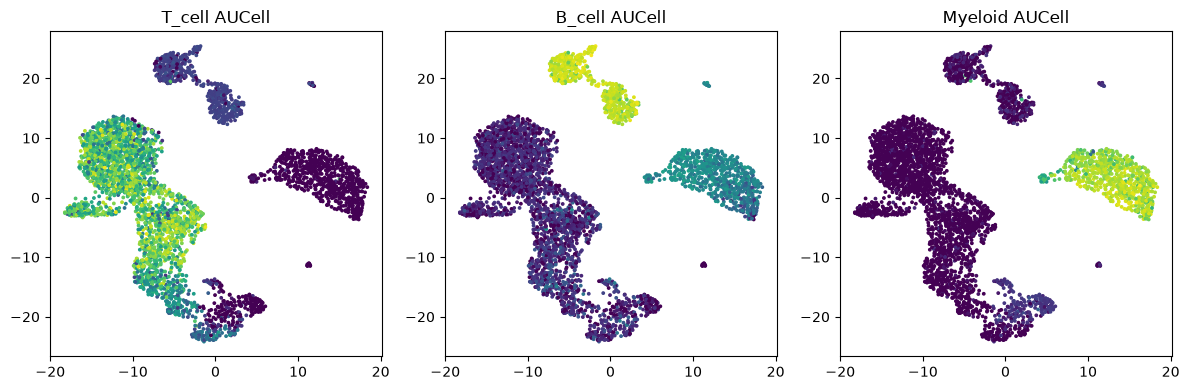

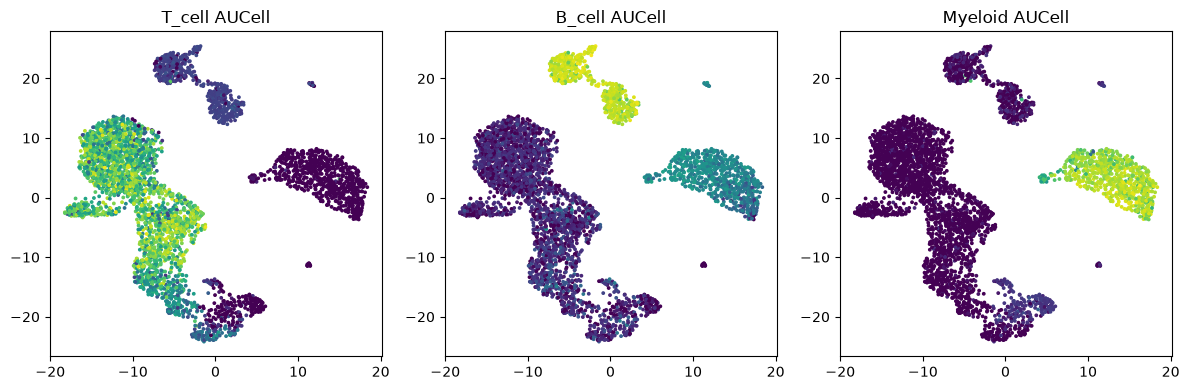

In [9]:
umap = run.cells.to_pandas_dataframe(['umap_1', 'umap_2'])
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, source in zip(axes, score_sources, strict=True):
    axis.scatter(
        umap['umap_1'],
        umap['umap_2'],
        c=aucell_scores[source],
        s=3,
    )
    axis.set_title(f'{source} AUCell')
figure.tight_layout()
figure

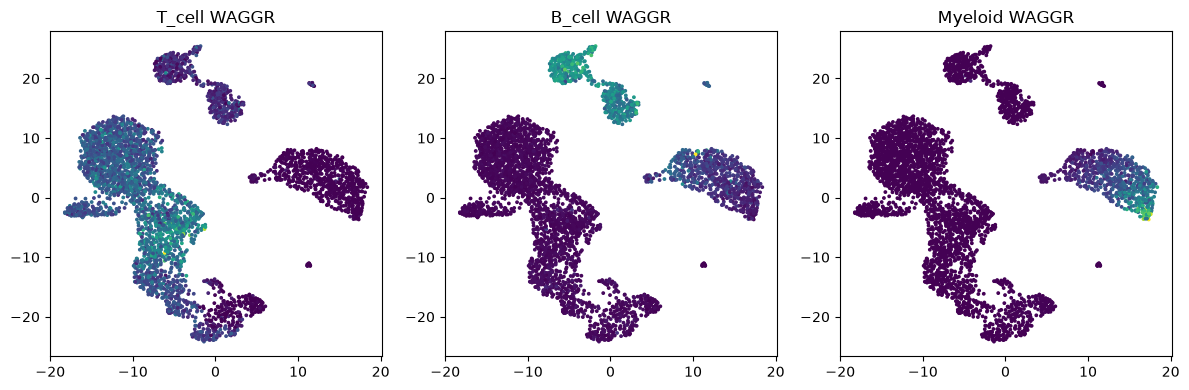

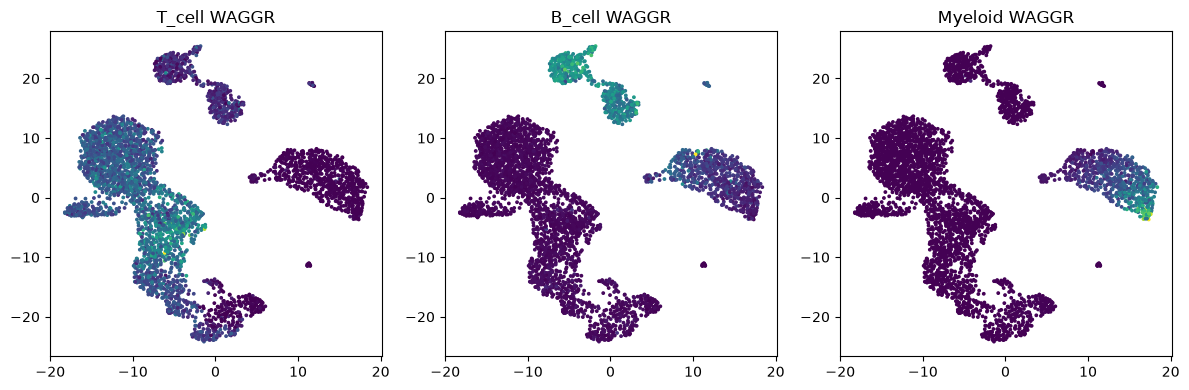

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, source in zip(axes, score_sources, strict=True):
    axis.scatter(
        umap['umap_1'],
        umap['umap_2'],
        c=waggr_scores[source],
        s=3,
    )
    axis.set_title(f'{source} WAGGR')
figure.tight_layout()
figure

In [11]:
myeloid_compare = pd.DataFrame(
    {
        'Myeloid_WAGGR': waggr_scores['Myeloid'],
        'Myeloid_AUCell': aucell_scores['Myeloid'],
    }
)
myeloid_compare.describe()

,Myeloid_WAGGR,Myeloid_AUCell
count,3940.000000,3940.000000
mean,1.453040,0.164952
std,3.650681,0.311867
min,0.000000,0.000000
25%,0.019388,0.000000
50%,0.042977,0.000000
75%,0.121820,0.106237
max,30.974056,0.951308


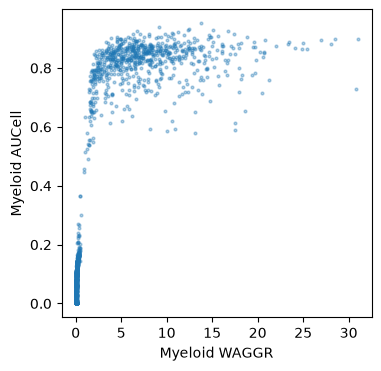

In [12]:
figure, axis = plt.subplots(figsize=(4, 4))
axis.scatter(
    myeloid_compare['Myeloid_WAGGR'],
    myeloid_compare['Myeloid_AUCell'],
    s=4,
    alpha=0.35,
)
axis.set_xlabel('Myeloid WAGGR')
axis.set_ylabel('Myeloid AUCell')
plt.show()